In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt

from cochleasim.models.cochlear_model import solve_pressure, displacement_from_pressure
from cochleasim.models.params_loader import CAT_PARAMS

p = CAT_PARAMS

In [2]:
f_hz = 6400
omega = 2 * np.pi * f_hz

x, Pd = solve_pressure(omega, Pe=1.0, params=p, N=251)

print("Pd en la base   (x=0):", Pd[0])
print("Pd en el ápice  (x=L):", Pd[-1])
print("|Pd| máximo (dB):", 20*np.log10(np.abs(Pd).max()))
print("posición del pico (x/L):", x[np.argmax(np.abs(Pd))] / p.L)

Pd en la base   (x=0): (72.65774268994599+6.3260704286021365j)
Pd en el ápice  (x=L): 0j
|Pd| máximo (dB): 51.672689368823754
posición del pico (x/L): 0.32


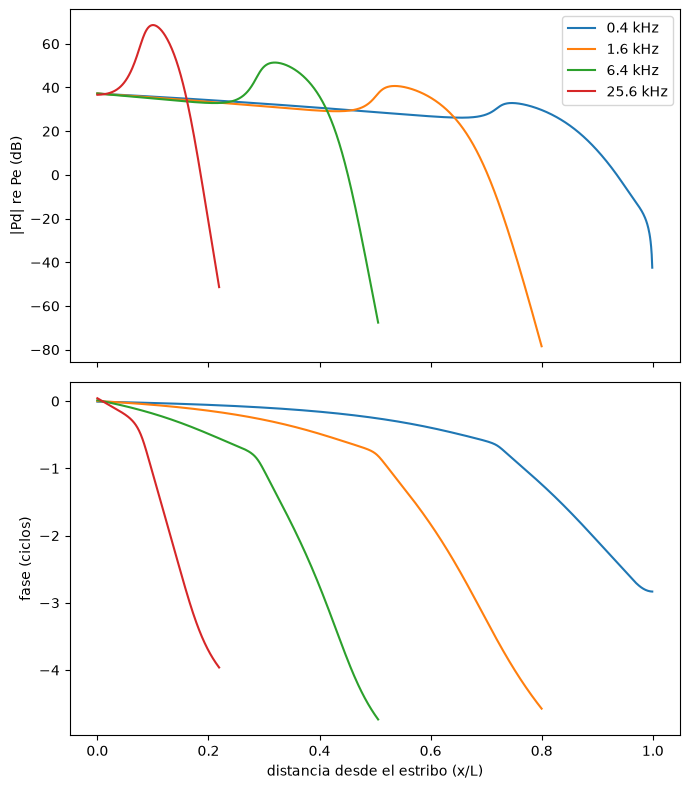

In [4]:
freqs_khz = [0.4, 1.6, 6.4, 25.6]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 8), sharex=True)
for f in freqs_khz:
    omega = 2 * np.pi * f * 1000
    x, Pd = solve_pressure(omega, Pe=1.0, params=p, N=1000)
    mag = np.abs(Pd)
    mask = mag > 1e-6 * mag.max()
    ax1.plot((x/p.L)[mask], 20*np.log10(mag[mask]), label=f"{f} kHz")
    ax2.plot((x/p.L)[mask], np.unwrap(np.angle(Pd[mask])) / (2*np.pi), label=f"{f} kHz")

ax1.set_ylabel("|Pd| re Pe (dB)")
ax1.legend()
ax2.set_ylabel("fase (ciclos)")
ax2.set_xlabel("distancia desde el estribo (x/L)")
plt.tight_layout()
plt.show()

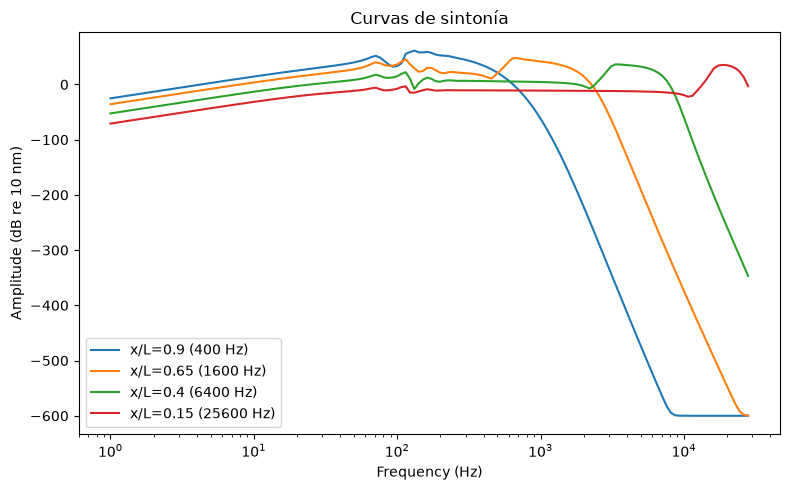

In [5]:
posiciones = {"400 Hz": 0.90, "1600 Hz": 0.65, "6400 Hz": 0.40, "25600 Hz": 0.15}
freqs = np.logspace(0, np.log10(28000), 150)  # 1 Hz a 28 kHz, como en el paper
N = 1000

fig, ax = plt.subplots(figsize=(8, 5))

for label, xL in posiciones.items():
    idx_target = int(round(xL * (N - 1)))
    mags = []
    for f in freqs:
        omega = 2 * np.pi * f
        x, Pd = solve_pressure(omega, Pe=1.0, params=p, N=N)
        xi_b, xi_c = displacement_from_pressure(x[idx_target], Pd[idx_target], omega, p)
        xi_b_nm = abs(xi_b) * 1e7  # cm -> nm
        mags.append(20 * np.log10(xi_b_nm / 10 + 1e-30))
    ax.semilogx(freqs, mags, label=f"x/L={xL} ({label})")

ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Amplitude (dB re 10 nm)")
ax.legend()
ax.set_title("Curvas de sintonía")
plt.tight_layout()
plt.show()

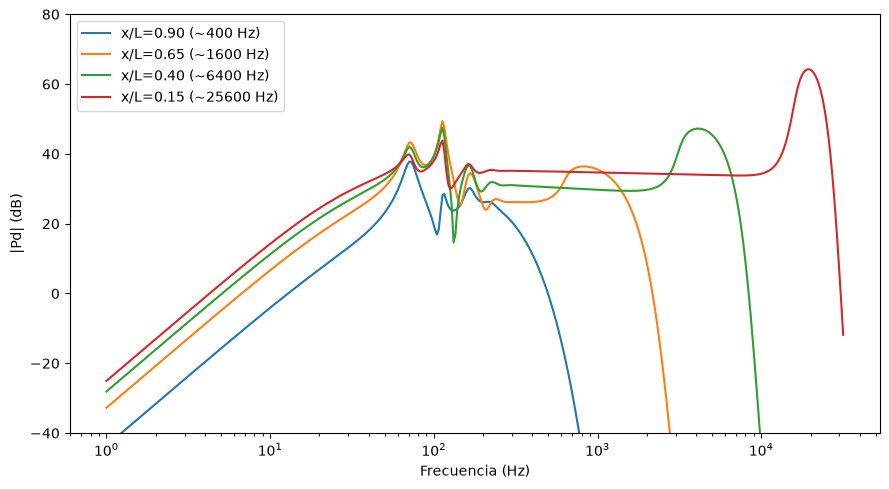

In [6]:
from cochleasim.models.cochlear_model import solve_pressure, partition_impedance

posiciones = {"x/L=0.90 (~400 Hz)": 0.90, "x/L=0.65 (~1600 Hz)": 0.65,
              "x/L=0.40 (~6400 Hz)": 0.40, "x/L=0.15 (~25600 Hz)": 0.15}

freqs = np.logspace(0, 4.5, 400)  # 1 Hz a ~32 kHz, buena resolucion
N = 1000

resultados = {}
for label, xL in posiciones.items():
    idx = int(round(xL * (N - 1)))
    mags = []
    for f in freqs:
        omega = 2*np.pi*f
        x, Pd = solve_pressure(omega, Pe=1.0, params=p, N=N)
        mags.append(abs(Pd[idx]))
    resultados[label] = np.array(mags)

fig, ax = plt.subplots(figsize=(9,5))
for label, mags in resultados.items():
    ax.semilogx(freqs, 20*np.log10(mags+1e-30), label=label)
ax.set_xlabel("Frecuencia (Hz)")
ax.set_ylabel("|Pd| (dB)")
ax.set_ylim(-40, 80)
ax.legend()
plt.tight_layout()
plt.show()

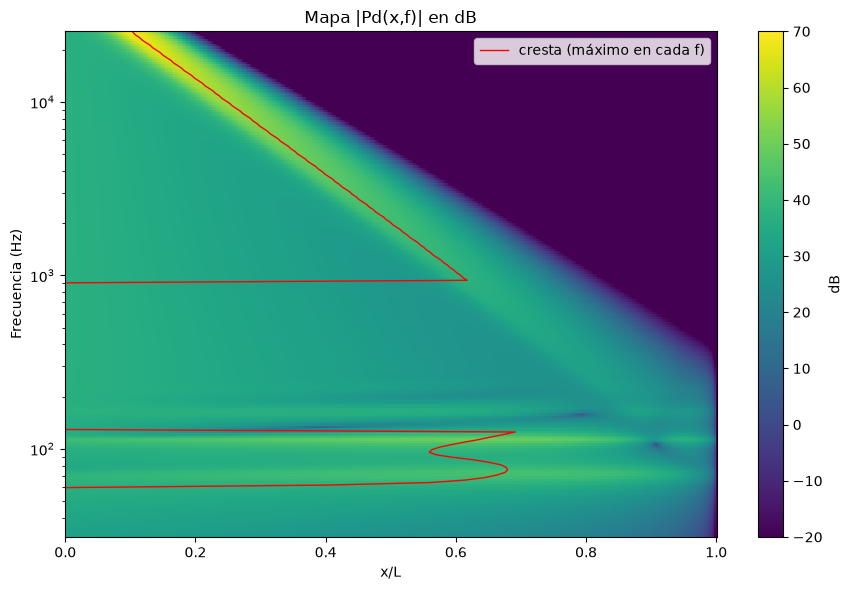

     31.6 Hz -> cresta en x/L=0.000
     52.3 Hz -> cresta en x/L=0.000
     86.5 Hz -> cresta en x/L=0.627
    143.1 Hz -> cresta en x/L=0.000
    236.8 Hz -> cresta en x/L=0.000
    391.7 Hz -> cresta en x/L=0.000
    648.0 Hz -> cresta en x/L=0.000
   1071.9 Hz -> cresta en x/L=0.597
   1773.1 Hz -> cresta en x/L=0.519
   2933.2 Hz -> cresta en x/L=0.441
   4852.1 Hz -> cresta en x/L=0.363
   8026.4 Hz -> cresta en x/L=0.285
  13277.5 Hz -> cresta en x/L=0.204
  21963.9 Hz -> cresta en x/L=0.124


In [6]:
N_mapa = 500
freqs_mapa = np.logspace(1.5, 4.4, 200)

superficie = np.zeros((len(freqs_mapa), N_mapa))
x_mapa = None
for i, f in enumerate(freqs_mapa):
    omega = 2*np.pi*f
    x_mapa, Pd = solve_pressure(omega, Pe=1.0, params=p, N=N_mapa)
    superficie[i, :] = 20*np.log10(np.abs(Pd) + 1e-30)

cresta_x = x_mapa[np.argmax(superficie, axis=1)] / p.L
assert cresta_x.shape == freqs_mapa.shape, (cresta_x.shape, freqs_mapa.shape)  # para pillarlo pronto si vuelve a pasar

fig, ax = plt.subplots(figsize=(9, 6))
im = ax.pcolormesh(x_mapa/p.L, freqs_mapa, superficie, shading='auto', vmin=-20, vmax=70, cmap='viridis')
ax.set_yscale('log')
ax.set_xlabel('x/L')
ax.set_ylabel('Frecuencia (Hz)')
ax.set_title('Mapa |Pd(x,f)| en dB')
ax.plot(cresta_x, freqs_mapa, color='red', linewidth=1, label='cresta (máximo en cada f)')
ax.legend()
plt.colorbar(im, label='dB')
plt.tight_layout()
plt.show()

for f, xc in zip(freqs_mapa[::15], cresta_x[::15]):
    print(f"{f:9.1f} Hz -> cresta en x/L={xc:.3f}")

In [7]:
def pico_exacto(omega, N=1000):
    x, Pd = solve_pressure(omega, Pe=1.0, params=p, N=N)
    idx = np.argmax(np.abs(Pd))
    return idx, x[idx]

def frecuencia_inversa(idx, f_min=300, f_max=1e4, n=60, N=1000):
    freqs_inv = np.logspace(np.log10(f_min), np.log10(f_max), n)
    mags = []
    for f in freqs_inv:
        omega = 2*np.pi*f
        x, Pd = solve_pressure(omega, Pe=1.0, params=p, N=N)
        mags.append(abs(Pd[idx]))
    return freqs_inv[np.argmax(mags)]

for f0 in [100,500,1000, 1600, 3200, 6400, 8800, 12800, 25600]:
    omega0 = 2*np.pi*f0
    idx, xL = pico_exacto(omega0)
    f_inv = frecuencia_inversa(idx)
    print(f"f0={f0:6d} Hz -> pico en x/L={xL/p.L:.4f} -> frecuencia inversa={f_inv:8.1f} Hz  (ratio={f_inv/f0:.3f})")

f0=   100 Hz -> pico en x/L=0.5656 -> frecuencia inversa=  1406.8 Hz  (ratio=14.068)
f0=   500 Hz -> pico en x/L=0.0000 -> frecuencia inversa=  2401.7 Hz  (ratio=4.803)
f0=  1000 Hz -> pico en x/L=0.6076 -> frecuencia inversa=  1109.1 Hz  (ratio=1.109)
f0=  1600 Hz -> pico en x/L=0.5355 -> frecuencia inversa=  1784.3 Hz  (ratio=1.115)
f0=  3200 Hz -> pico en x/L=0.4274 -> frecuencia inversa=  3430.8 Hz  (ratio=1.072)
f0=  6400 Hz -> pico en x/L=0.3193 -> frecuencia inversa=  7000.5 Hz  (ratio=1.094)
f0=  8800 Hz -> pico en x/L=0.2693 -> frecuencia inversa=  9423.0 Hz  (ratio=1.071)
f0= 12800 Hz -> pico en x/L=0.2102 -> frecuencia inversa= 10000.0 Hz  (ratio=0.781)
f0= 25600 Hz -> pico en x/L=0.1001 -> frecuencia inversa=   300.0 Hz  (ratio=0.012)


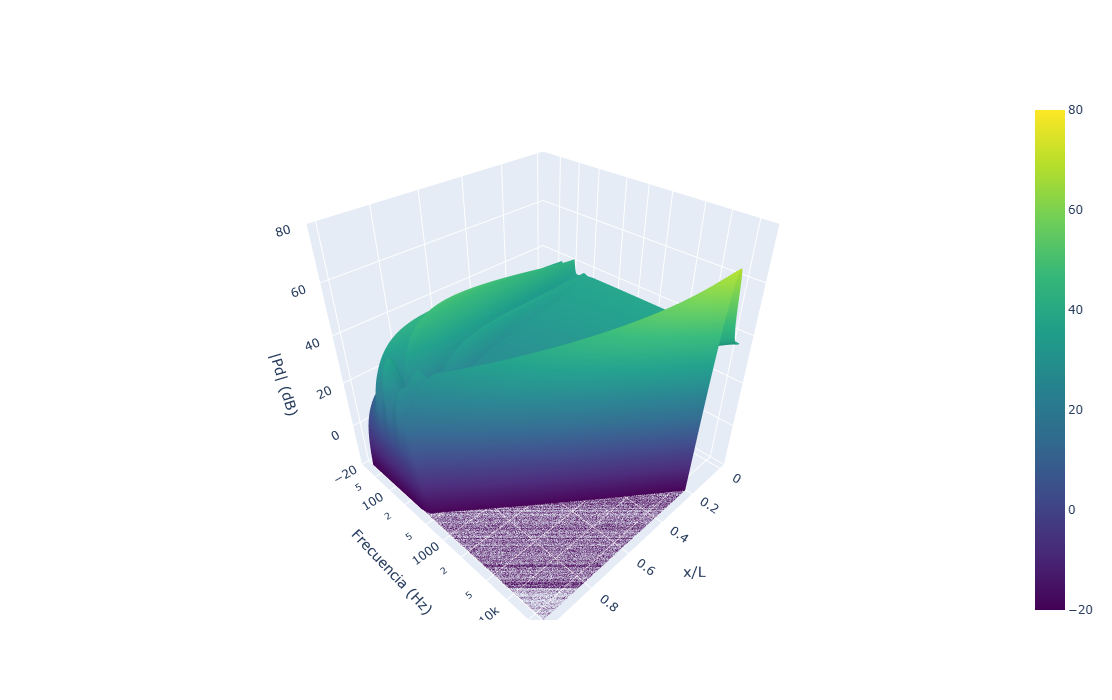

In [9]:
import plotly.graph_objects as go

SUELO_DB = -20
superficie_recortada = np.clip(superficie, SUELO_DB, None)

fig = go.Figure(data=[go.Surface(
    z=superficie_recortada,
    x=x_mapa / p.L,
    y=freqs_mapa,
    colorscale='Viridis',
    cmin=SUELO_DB, cmax=80,
    connectgaps=False,          # que no intente rellenar los huecos interpolando
    lighting=dict(ambient=0.9, diffuse=0.3, specular=0.05, roughness=0.9, fresnel=0.05),
    lightposition=dict(x=0, y=0, z=10000),
)])
fig.update_layout(
    scene=dict(
        xaxis_title='x/L',
        yaxis_title='Frecuencia (Hz)',
        yaxis_type='log',
        zaxis_title='|Pd| (dB)',
        zaxis=dict(range=[SUELO_DB, 80]),
    ),
    width=900, height=700,
)
fig.show()